# **SECTION 1: IMPORTING NECESSARY LIBRARIES**

In [ ]:
import requests          # Makes HTTP requests to fetch web pages
from bs4 import BeautifulSoup  # Parses HTML into searchable tree structure
import pandas as pd      # Creates DataFrames and exports to CSV/Excel
import re                # Pattern matching for text cleaning (built-in)
import json              # Parses JSON data embedded in web pages (built-in)
from datetime import datetime  # Generates timestamps for filenames (built-in)

# **SECTION 2: CONFIGURATION**

In [ ]:
# Target URL - IMDb's Top 250 movies chart page
URL = "https://www.imdb.com/chart/top/"

# HTTP Headers
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8"
}

# **SECTION 3: FETCH PAGE CONTENT**

In [ ]:
# Function to fetch the page content
def fetch_page(url, headers):
    """Fetch webpage content with error handling."""
    try:
        response = requests.get(url, headers=headers, timeout=10)  # 10 sec timeout
        response.raise_for_status()  # Raises exception for 4xx/5xx status codes
        print(f"✓ Successfully fetched page. Status: {response.status_code}")
        return response.text  # Returns HTML as string
    except requests.RequestException as e:
        print(f"✗ Error fetching page: {e}")
        return None

# Execute the function
html_content = fetch_page(URL, HEADERS)

✓ Successfully fetched page. Status: 200


# **SECTION 4: PARSE WITH BEAUTIFULSOUP**

In [ ]:
soup = BeautifulSoup(html_content, 'html.parser')

# ---------- STEP 1: Parse __NEXT_DATA__ (has ALL movie details) ----------
page_script = soup.find('script', id='__NEXT_DATA__')
movies_data = []

if page_script:
    try:
        next_data = json.loads(page_script.string)
        edges = next_data['props']['pageProps']['pageData']['chartTitles']['edges']

        for idx, edge in enumerate(edges, 1):
            node = edge.get('node', {})

            # Extract all fields directly from __NEXT_DATA__
            title = node.get('titleText', {}).get('text', '')
            year = node.get('releaseYear', {}).get('year', None)
            rating_obj = node.get('ratingsSummary', {})
            runtime_obj = node.get('runtime', {})

            # Get genres (list of genre objects)
            genres_list = node.get('titleGenres', {}).get('genres', [])
            genres = ', '.join([g.get('genre', {}).get('text', '') for g in genres_list])

            # Get certificate (content rating)
            cert_obj = node.get('certificate', {})

            movies_data.append({
                'rank': idx,
                'title': title,
                'year': year,
                'rating': rating_obj.get('aggregateRating'),
                'rating_count': rating_obj.get('voteCount'),
                'duration_seconds': runtime_obj.get('seconds'),
                'duration': f"{runtime_obj.get('seconds', 0) // 3600}h {(runtime_obj.get('seconds', 0) % 3600) // 60}m" if runtime_obj.get('seconds') else None,
                'genre': genres if genres else None,
                'content_rating': cert_obj.get('rating') if cert_obj else None,
                'imdb_id': node.get('id'),
                'url': f"https://www.imdb.com/title/{node.get('id')}/"
            })

        print(f"✓ Parsed {len(movies_data)} movies from __NEXT_DATA__")

    except (json.JSONDecodeError, KeyError, TypeError) as e:
        print(f"✗ Error parsing __NEXT_DATA__: {e}")

# ---------- STEP 2: Verify data completeness ----------
years_found = sum(1 for m in movies_data if m['year'] is not None)
ratings_found = sum(1 for m in movies_data if m['rating'] is not None)

print(f"✓ Years found: {years_found}/250")
print(f"✓ Ratings found: {ratings_found}/250")

# Show any movies still missing year
missing_years = [m['title'] for m in movies_data if m['year'] is None]
if missing_years:
    print(f"\n→ Movies missing year: {missing_years[:5]}...")

print(f"\nSample movie:\n{movies_data[0]}")

✓ Parsed 250 movies from __NEXT_DATA__
✓ Years found: 250/250
✓ Ratings found: 250/250

Sample movie:
{'rank': 1, 'title': 'The Shawshank Redemption', 'year': 1994, 'rating': 9.3, 'rating_count': 3151478, 'duration_seconds': 8520, 'duration': '2h 22m', 'genre': 'Drama', 'content_rating': 'R', 'imdb_id': 'tt0111161', 'url': 'https://www.imdb.com/title/tt0111161/'}


# **SECTION 5: CREATE DATAFRAME**

In [ ]:
# Convert list of dictionaries to DataFrame
df = pd.DataFrame(movies_data)

# Helper function to convert ISO 8601 duration (PT2H22M) to readable format (2h 22m)
def parse_duration(iso_duration):
    if not iso_duration or not isinstance(iso_duration, str):
        return iso_duration
    match = re.match(r'PT(?:(\d+)H)?(?:(\d+)M)?', iso_duration)
    if match:
        hours = int(match.group(1) or 0)
        minutes = int(match.group(2) or 0)
        return f"{hours}h {minutes}m" if hours else f"{minutes}m"
    return iso_duration

# Apply duration formatting
if 'duration' in df.columns:
    df['duration_formatted'] = df['duration'].apply(parse_duration)

# Extract year from date_published (will likely be NaN if date_published is None)
if 'date_published' in df.columns:
    df['year'] = pd.to_datetime(df['date_published'], errors='coerce').dt.year

# Fallback: Extract year from title if 'year' is still missing
# This regex looks for a four-digit year in parentheses at the end of the title
if 'year' in df.columns:
    df['year'] = df.apply(lambda row:
        row['year'] if pd.notna(row['year']) else
        (int(re.search(r'\((\d{4})\)', row['title']).group(1)) if re.search(r'\((\d{4})\)', row['title']) else None),
        axis=1
    )

# Preview the DataFrame
print("DataFrame Preview:")
print(df.head(100))

DataFrame Preview:
    rank                                  title  year  rating  rating_count  \
0      1               The Shawshank Redemption  1994     9.3       3151478   
1      2                          The Godfather  1972     9.2       2199205   
2      3                        The Dark Knight  2008     9.1       3127344   
3      4                  The Godfather Part II  1974     9.0       1478345   
4      5                           12 Angry Men  1957     9.0        971368   
..   ...                                    ...   ...     ...           ...   
95    96                              Incendies  2010     8.3        244936   
96    97  Eternal Sunshine of the Spotless Mind  2004     8.3       1170432   
97    98                          The Apartment  1960     8.3        216967   
98    99                     Lawrence of Arabia  1962     8.3        338610   
99   100                  2001: A Space Odyssey  1968     8.3        775212   

    duration_seconds duration   

# **SECTION 6: DATAFRAME INFO & STATISTICS**

In [ ]:
# Basic DataFrame info
print("="*60)
print("DATAFRAME OVERVIEW")
print("="*60)
print(f"Total Movies: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print(f"Columns: {list(df.columns)}")

# Data types of each column
print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

# Check for missing values
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

# Rating statistics
print("\n" + "="*60)
print("RATING STATISTICS")
print("="*60)
if 'rating' in df.columns:
    print(f"Mean Rating:   {df['rating'].mean():.2f}")
    print(f"Median Rating: {df['rating'].median():.2f}")
    print(f"Min Rating:    {df['rating'].min()}")
    print(f"Max Rating:    {df['rating'].max()}")
    print(f"Std Deviation: {df['rating'].std():.2f}")

DATAFRAME OVERVIEW
Total Movies: 250
Total Columns: 12
Columns: ['rank', 'title', 'year', 'rating', 'rating_count', 'duration_seconds', 'duration', 'genre', 'content_rating', 'imdb_id', 'url', 'duration_formatted']

DATA TYPES
rank                    int64
title                  object
year                    int64
rating                float64
rating_count            int64
duration_seconds        int64
duration               object
genre                  object
content_rating         object
imdb_id                object
url                    object
duration_formatted     object
dtype: object

MISSING VALUES
rank                  0
title                 0
year                  0
rating                0
rating_count          0
duration_seconds      0
duration              0
genre                 0
content_rating        5
imdb_id               0
url                   0
duration_formatted    0
dtype: int64

RATING STATISTICS
Mean Rating:   8.31
Median Rating: 8.20
Min Rating:    8.0
Max 

# **SECTION 7: EDA UNIVARIATE ANALYSIS**

In [ ]:
import matplotlib.pyplot as plt  # For creating charts

# **7.1 RATING DISTRIBUTION**

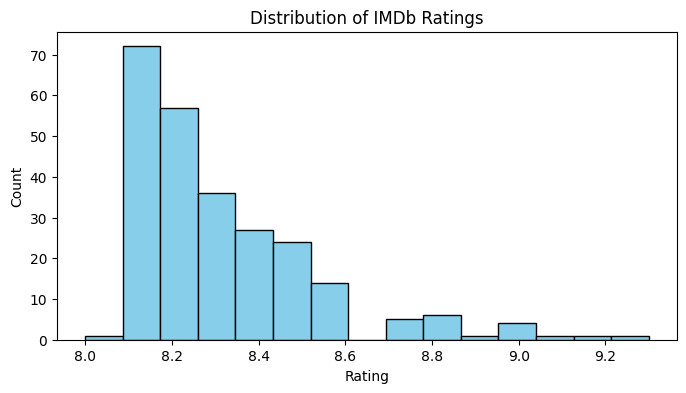

Min Rating: 8.0
Max Rating: 9.3
Average Rating: 8.31


In [ ]:
plt.figure(figsize=(8, 4))  # Set chart size (width, height)
plt.hist(df['rating'], bins=15, color='skyblue', edgecolor='black')  # Create histogram
plt.title('Distribution of IMDb Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

print(f"Min Rating: {df['rating'].min()}")
print(f"Max Rating: {df['rating'].max()}")
print(f"Average Rating: {df['rating'].mean():.2f}")  # :.2f means 2 decimal places


# **7.2 YEAR DISTRIBUTION**

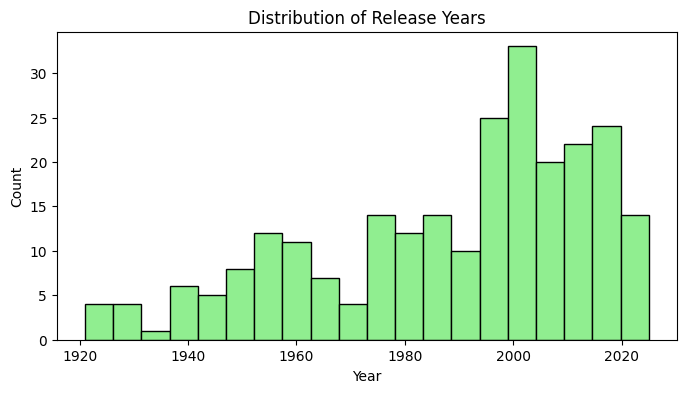

Oldest Movie: 1921
Newest Movie: 2025


In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df['year'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of Release Years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

print(f"Oldest Movie: {df['year'].min()}")
print(f"Newest Movie: {df['year'].max()}")

# **7.3 DECADE DISTRIBUTION**

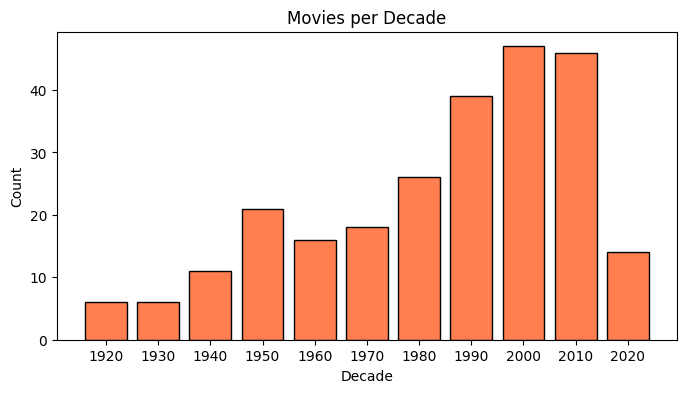

decade
1920     6
1930     6
1940    11
1950    21
1960    16
1970    18
1980    26
1990    39
2000    47
2010    46
2020    14
Name: count, dtype: int64


In [ ]:
df['decade'] = (df['year'] // 10) * 10  # Convert year to decade (1994 -> 1990)
decade_counts = df['decade'].value_counts().sort_index()  # Count movies per decade

plt.figure(figsize=(8, 4))
plt.bar(decade_counts.index.astype(str), decade_counts.values, color='coral', edgecolor='black')
plt.title('Movies per Decade')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.show()

print(decade_counts)

# **7.4 DURATION DISTRIBUTION**

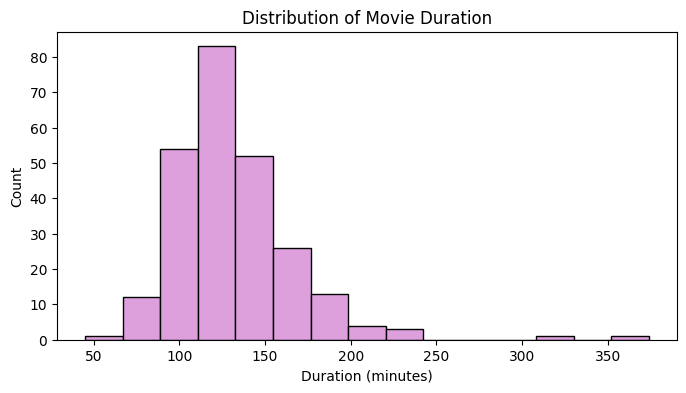

Shortest: 45 mins
Longest: 374 mins
Average: 132 mins


In [ ]:
df['duration_mins'] = df['duration_seconds'] / 60  # Convert seconds to minutes

plt.figure(figsize=(8, 4))
plt.hist(df['duration_mins'], bins=15, color='plum', edgecolor='black')
plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.show()

print(f"Shortest: {df['duration_mins'].min():.0f} mins")
print(f"Longest: {df['duration_mins'].max():.0f} mins")
print(f"Average: {df['duration_mins'].mean():.0f} mins")

# **7.5 RATING COUNT (VOTES) DISTRIBUTION**

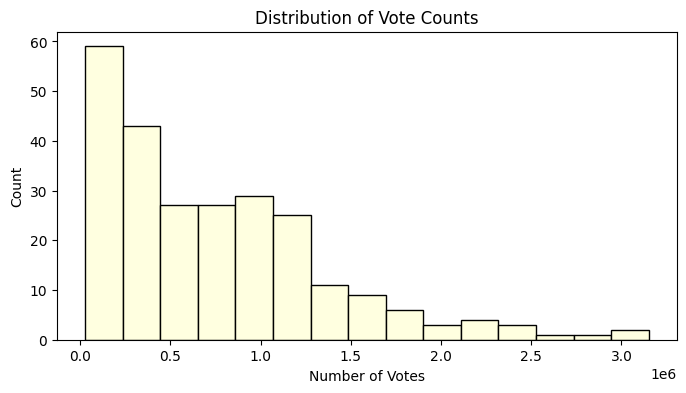

Least Votes: 27,480
Most Votes: 3,151,478


In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df['rating_count'], bins=15, color='lightyellow', edgecolor='black')
plt.title('Distribution of Vote Counts')
plt.xlabel('Number of Votes')
plt.ylabel('Count')
plt.show()

print(f"Least Votes: {df['rating_count'].min():,}")  # :, adds comma separator
print(f"Most Votes: {df['rating_count'].max():,}")

# **7.6 GENRE DISTRIBUTION**

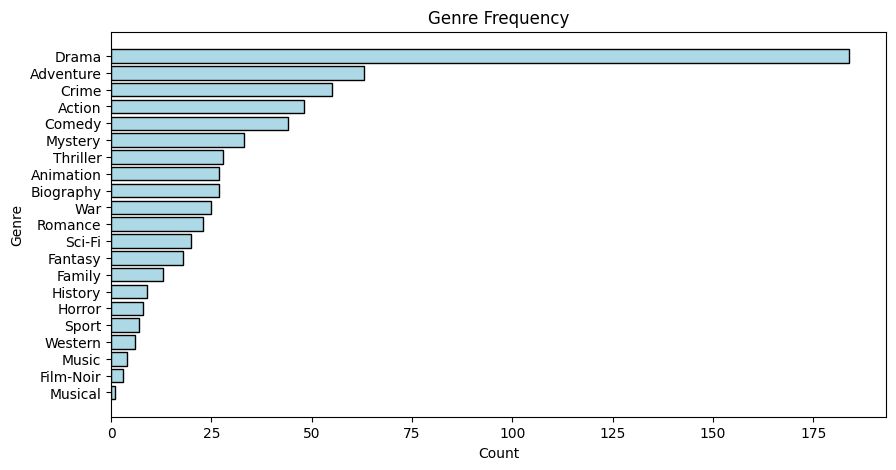

genre
Drama        184
Adventure     63
Crime         55
Action        48
Comedy        44
Mystery       33
Thriller      28
Animation     27
Biography     27
War           25
Romance       23
Sci-Fi        20
Fantasy       18
Family        13
History        9
Horror         8
Sport          7
Western        6
Music          4
Film-Noir      3
Musical        1
Name: count, dtype: int64


In [ ]:
# Split genres ("Drama, Crime" -> ["Drama", "Crime"]) and count each
all_genres = df['genre'].str.split(', ').explode()
genre_counts = all_genres.value_counts()

plt.figure(figsize=(10, 5))
plt.barh(genre_counts.index, genre_counts.values, color='lightblue', edgecolor='black')
plt.title('Genre Frequency')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()  # Put highest count at top
plt.show()

print(genre_counts)

# **7.7 CONTENT RATING DISTRIBUTION**

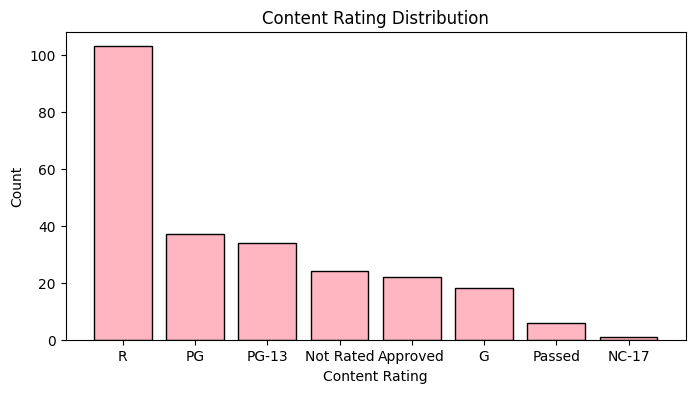

content_rating
R            103
PG            37
PG-13         34
Not Rated     24
Approved      22
G             18
Passed         6
NC-17          1
Name: count, dtype: int64


In [ ]:
content_counts = df['content_rating'].value_counts()  # Count each rating type

plt.figure(figsize=(8, 4))
plt.bar(content_counts.index, content_counts.values, color='lightpink', edgecolor='black')
plt.title('Content Rating Distribution')
plt.xlabel('Content Rating')
plt.ylabel('Count')
plt.show()

print(content_counts)

# **SECTION 8: EDA BIVARIATE ANALYSIS**

# **8.1 RATING vs YEAR (Scatter Plot)**

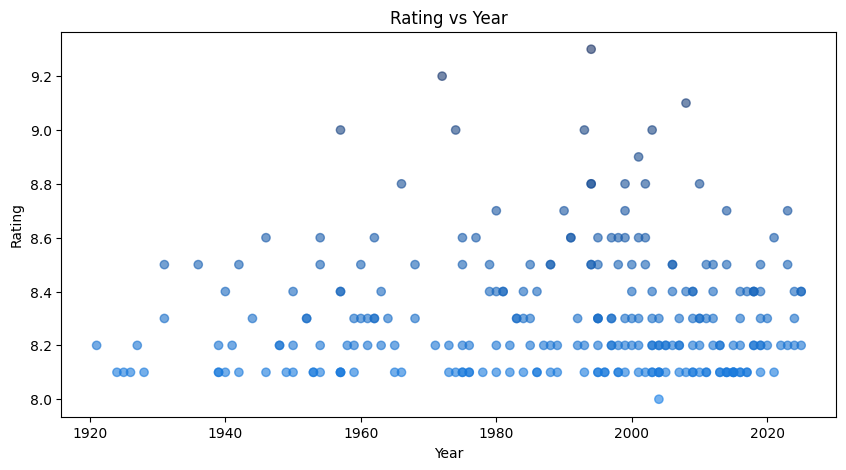

In [ ]:
# Helper function to create blue color gradient (dark to light based on value)
def get_colors(values):
    normalized = (values - values.min()) / (values.max() - values.min())
    return [(0.1, 0.2 + 0.3 * (1 - n), 0.4 + 0.5 * (1 - n)) for n in normalized]

colors_1 = get_colors(df['rating'])

plt.figure(figsize=(10, 5))
plt.scatter(df['year'], df['rating'], alpha=0.6, c=colors_1)
plt.title('Rating vs Year')
plt.xlabel('Year')
plt.ylabel('Rating')
plt.show()

# **8.1.1 Rating vs Year Overview**

The scatter plot of 'Rating vs Year' shows how movie ratings are distributed across different release years.

*   **Relatively Consistent High Ratings:** The plot indicates that movies consistently maintain high ratings (mostly above 8.0) across all decades, reflecting the nature of IMDb's Top 250 list.
*   **Concentration in Recent Decades:** There appears to be a higher concentration of movies from more recent decades, especially from the 1990s and 2000s, suggesting a larger volume of highly-rated films in those periods.
*   **No Strong Linear Trend:** There isn't a clear linear relationship showing ratings increasing or decreasing significantly with time, reinforcing that excellent films have been produced throughout cinematic history.

# **8.2 RATING vs DECADE (Box Plot)**

/tmp/ipython-input-2968465042.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_by_decade, labels=decades, patch_artist=True)


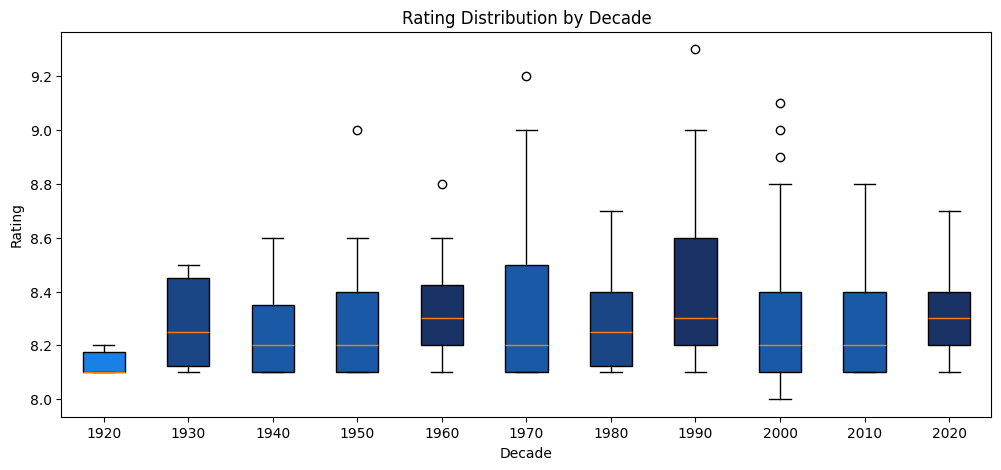

Average Rating by Decade:
decade
1920    8.13
1930    8.28
1940    8.25
1950    8.28
1960    8.34
1970    8.35
1980    8.28
1990    8.41
2000    8.31
2010    8.26
2020    8.34
Name: rating, dtype: float64


In [ ]:
decades = sorted(df['decade'].unique())

plt.figure(figsize=(12, 5))
data_by_decade = [df[df['decade'] == d]['rating'] for d in decades]
box = plt.boxplot(data_by_decade, labels=decades, patch_artist=True)

medians = [d.median() for d in data_by_decade]
colors_2 = get_colors(pd.Series(medians))
for patch, color in zip(box['boxes'], colors_2):
    patch.set_facecolor(color)

plt.title('Rating Distribution by Decade')
plt.xlabel('Decade')
plt.ylabel('Rating')
plt.show()

print("Average Rating by Decade:")
print(df.groupby('decade')['rating'].mean().round(2))

# **8.2.1 Rating Distribution by Decade Overview**

The box plot illustrates the distribution of IMDb ratings across different decades.

*   **Narrow Rating Range:** All decades show a very narrow range of ratings, which is expected for a 'Top 250' list where all movies are highly rated.
*   **Slight Variations in Medians:** While the overall ratings are high, there are slight variations in the median ratings across decades. The 1990s, for example, show a slightly higher average rating compared to other decades, indicating a particularly strong period for critically acclaimed films.
*   **Outliers are Rare:** Outliers (movies with ratings significantly different from the bulk of their decade's films) are not prominently visible, further emphasizing the consistent high quality within this curated list.

# **8.3 RATING vs DURATION (Scatter Plot)**

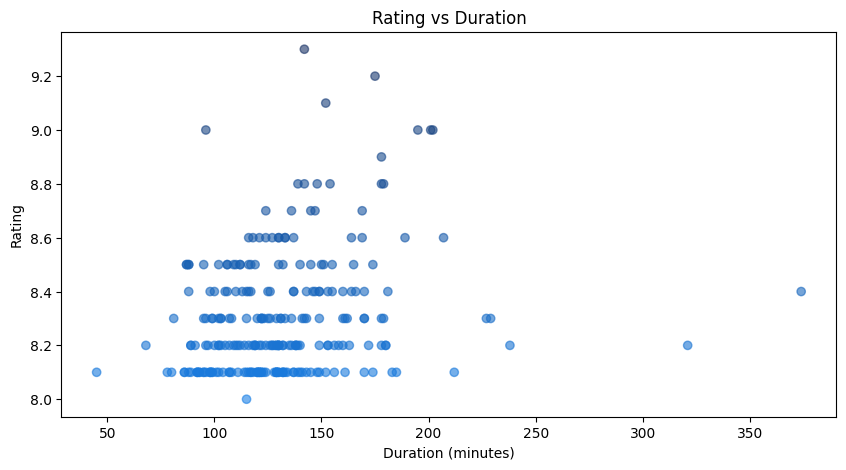

In [ ]:
colors_3 = get_colors(df['rating'])

plt.figure(figsize=(10, 5))
plt.scatter(df['duration_mins'], df['rating'], alpha=0.6, c=colors_3)
plt.title('Rating vs Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Rating')
plt.show()


# **8.3.1 Rating vs Duration Overview**

The scatter plot of 'Rating vs Duration' explores the relationship between a movie's length (in minutes) and its IMDb rating.

*   **Wide Range of Durations:** Highly-rated movies span a wide range of durations, from relatively short films (around 90 minutes) to very long ones (over 3 hours).
*   **Concentration Around Average Lengths:** There's a noticeable concentration of highly-rated films in the 120-180 minute (2-3 hour) range, suggesting that a substantial runtime is often associated with movies on this list.
*   **No Direct Correlation:** There isn't a strong linear correlation implying that longer movies are inherently better or worse rated. While very short films are rare on the list, both medium and epic-length movies achieve high ratings, indicating that duration itself is not a primary determinant of a top rating.

# **8.4 RATING vs RATING COUNT (Scatter Plot)**

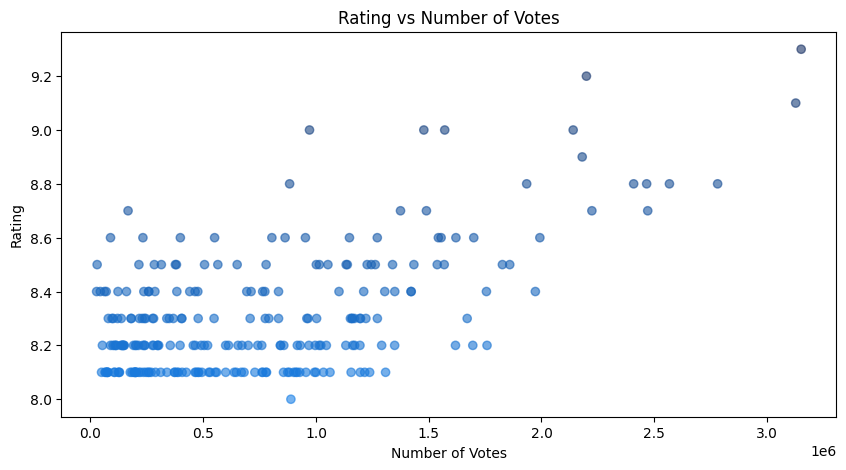

In [ ]:
colors_4 = get_colors(df['rating'])

plt.figure(figsize=(10, 5))
plt.scatter(df['rating_count'], df['rating'], alpha=0.6, c=colors_4)
plt.title('Rating vs Number of Votes')
plt.xlabel('Number of Votes')
plt.ylabel('Rating')
plt.show()

# **8.4.1 Rating vs Rating Count Overview**

This scatter plot visualizes the relationship between a movie's IMDb rating and the total number of votes it has received.

*   **Positive Correlation:** There is a clear positive correlation between a movie's rating and its vote count. Movies with higher ratings tend to have significantly more votes, suggesting that widely acclaimed films attract more viewers and active engagement.
*   **Varying Vote Counts for Similar Ratings:** While the trend is positive, movies with very similar high ratings can have vastly different vote counts. This could be due to factors like age, genre popularity, or cultural impact.
*   **High Engagement for Top-Rated Films:** The plot reinforces that the highest-rated films are also among the most watched and discussed, accumulating millions of votes.

# **8.5. RATING vs GENRE (Bar Chart)**

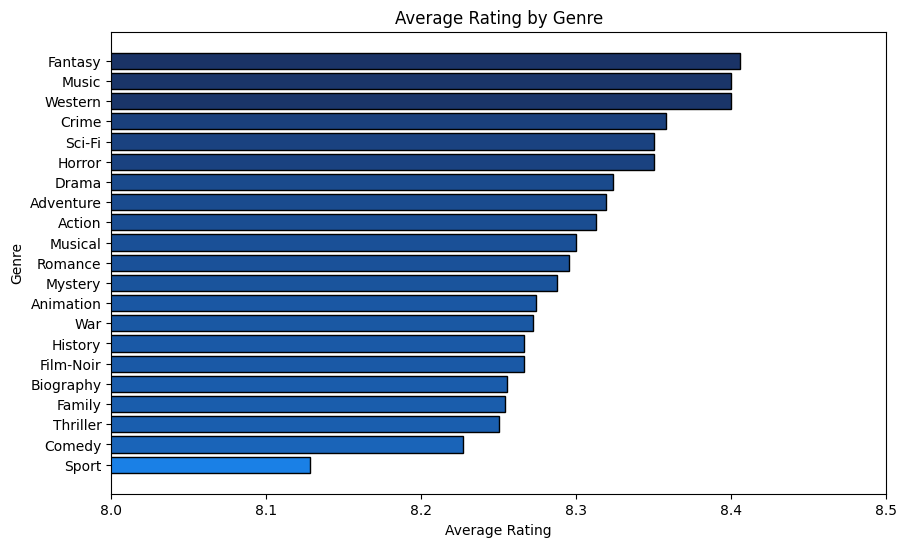

Average Rating by Genre:
genre
Fantasy      8.41
Music        8.40
Western      8.40
Crime        8.36
Sci-Fi       8.35
Horror       8.35
Drama        8.32
Adventure    8.32
Action       8.31
Musical      8.30
Romance      8.30
Mystery      8.29
Animation    8.27
War          8.27
History      8.27
Film-Noir    8.27
Biography    8.26
Family       8.25
Thriller     8.25
Comedy       8.23
Sport        8.13
Name: rating, dtype: float64


In [ ]:
all_genres = df['genre'].str.split(', ').explode()
genre_df = pd.DataFrame({'genre': all_genres.values, 'rating': df.loc[all_genres.index, 'rating'].values})
genre_avg = genre_df.groupby('genre')['rating'].mean().sort_values(ascending=False)

colors_5 = get_colors(genre_avg)

plt.figure(figsize=(10, 6))
plt.barh(genre_avg.index, genre_avg.values, color=colors_5, edgecolor='black')
plt.title('Average Rating by Genre')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.xlim(8, 8.5)
plt.gca().invert_yaxis()
plt.show()

print("Average Rating by Genre:")
print(genre_avg.round(2))

# **8.5.1 Rating vs Genre Overview**

The horizontal bar chart displays the average IMDb rating for each genre present in the dataset, sorted from highest to lowest average rating.

*   **Drama as a Dominant Force:** Drama films tend to have a consistently high average rating, often serving as the core or a significant component of many highly-rated movies.
*   **Variations Across Genres:** While all genres on this list have high average ratings (as they are part of the Top 250), there are subtle differences. Genres like Fantasy, Music, and Western appear to have slightly higher average ratings, while Sport and Comedy are marginally lower.
*   **Multi-Genre Films:** It's important to remember that many films belong to multiple genres, which can influence these averages. This chart primarily highlights the overall critical success associated with different categorical classifications.

# **8.6 RATING vs CONTENT RATING (Box Plot)**

/tmp/ipython-input-2922718514.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_by_content, labels=content_ratings, patch_artist=True)


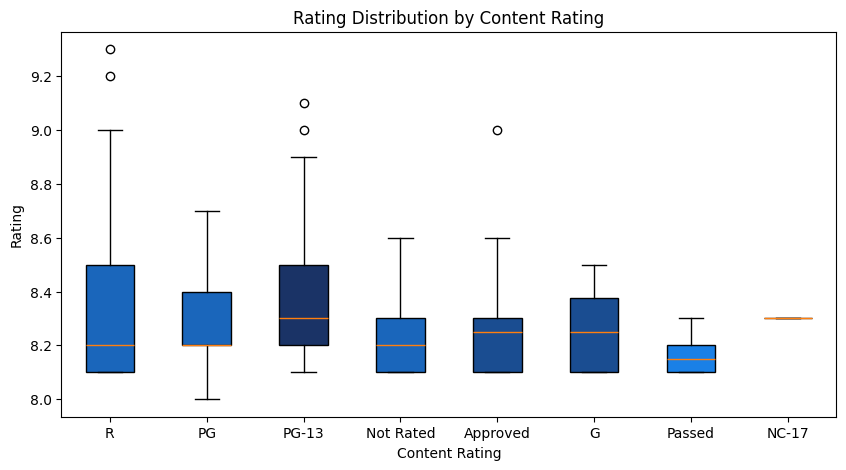

Average Rating by Content Rating:
content_rating
PG-13        8.38
R            8.33
NC-17        8.30
PG           8.29
Approved     8.28
G            8.26
Not Rated    8.22
Passed       8.17
Name: rating, dtype: float64


In [ ]:
content_ratings = df['content_rating'].value_counts().index.tolist()

plt.figure(figsize=(10, 5))
data_by_content = [df[df['content_rating'] == c]['rating'].dropna() for c in content_ratings]
box = plt.boxplot(data_by_content, labels=content_ratings, patch_artist=True)

medians_6 = [d.median() for d in data_by_content]
colors_6 = get_colors(pd.Series(medians_6))
for patch, color in zip(box['boxes'], colors_6):
    patch.set_facecolor(color)

plt.title('Rating Distribution by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Rating')
plt.show()

print("Average Rating by Content Rating:")
print(df.groupby('content_rating')['rating'].mean().round(2).sort_values(ascending=False))

# **8.6.1 Rating Distribution by Content Rating Overview**

This box plot shows the distribution of IMDb ratings based on their content rating (e.g., G, PG, R).

*   **High Ratings Across All Categories:** Similar to other analyses, the box plot shows that high ratings are prevalent across all content ratings, confirming the selection criteria of the Top 250 list.
*   **PG-13 and R Rated Films Often Highly Rated:** Movies with 'PG-13' and 'R' ratings tend to have some of the highest average ratings, suggesting that films targeting more mature audiences or with more complex themes often resonate highly with critics and audiences on IMDb.
*   **

# **8.7 DURATION vs DECADE (Bar Chart)**

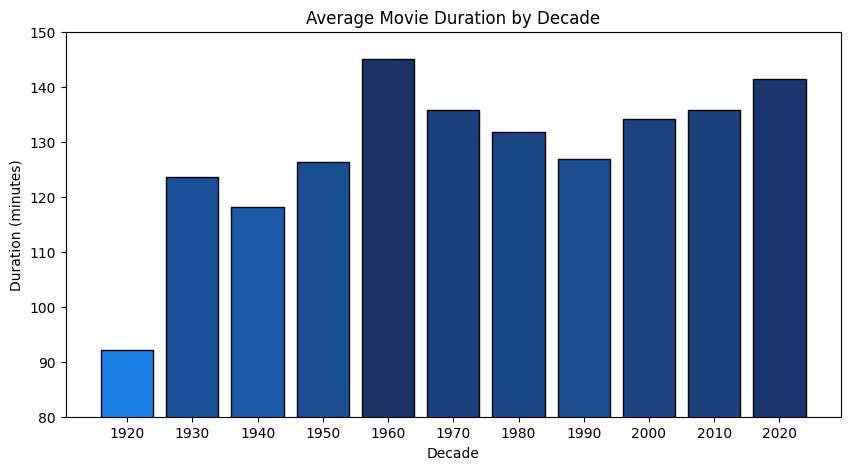

Average Duration by Decade (mins):
decade
1920     92.0
1930    124.0
1940    118.0
1950    126.0
1960    145.0
1970    136.0
1980    132.0
1990    127.0
2000    134.0
2010    136.0
2020    141.0
Name: duration_mins, dtype: float64


In [ ]:
avg_duration = df.groupby('decade')['duration_mins'].mean()
colors_7 = get_colors(avg_duration)

plt.figure(figsize=(10, 5))
plt.bar(avg_duration.index.astype(str), avg_duration.values, color=colors_7, edgecolor='black')
plt.title('Average Movie Duration by Decade')
plt.xlabel('Decade')
plt.ylabel('Duration (minutes)')
plt.ylim(80, 150)
plt.show()

print("Average Duration by Decade (mins):")
print(avg_duration.round(0))

# **8.7.1 Average Movie Duration by Decade Overview**

The bar chart illustrates the average duration of movies (in minutes) for each decade.

*   **Fluctuating Durations:** The average movie duration has fluctuated over the decades. There's not a consistent increase or decrease.
*   **Slight Increase in Recent Decades:** While not a strict linear trend, there's a noticeable increase in average duration in more recent decades (2000s and 2010s), with the 2020s currently showing the highest average duration. This might indicate a trend towards longer, more epic storytelling in modern cinema, or could be influenced by the smaller sample size for the current decade.
*   **1960s Peak:** The 1960s also show a significantly high average duration, possibly due to a number of epic films released during that era.

# **8.8 VOTES vs DECADE (Bar Chart)**

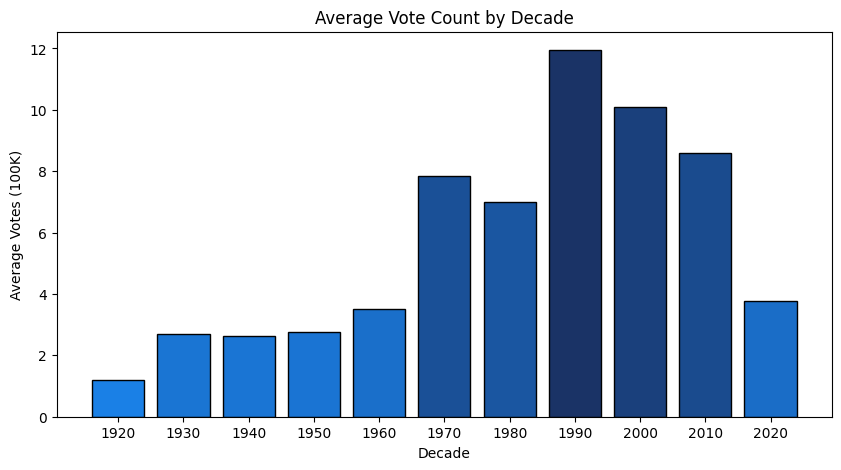

Average Votes by Decade (in 100K):
decade
1920     1.2
1930     2.7
1940     2.6
1950     2.8
1960     3.5
1970     7.8
1980     7.0
1990    11.9
2000    10.1
2010     8.6
2020     3.8
Name: rating_count, dtype: float64


In [ ]:
avg_votes = df.groupby('decade')['rating_count'].mean()
avg_votes_100k = avg_votes / 100_000  # Convert to 100K units
colors_8 = get_colors(avg_votes_100k)

plt.figure(figsize=(10, 5))
plt.bar(avg_votes_100k.index.astype(str), avg_votes_100k.values, color=colors_8, edgecolor='black')
plt.title('Average Vote Count by Decade')
plt.xlabel('Decade')
plt.ylabel('Average Votes (100K)')
plt.show()

print("Average Votes by Decade (in 100K):")
print(avg_votes_100k.round(1))


# **8.8.1 Average Vote Count by Decade Overview**

The bar chart depicting the average vote count by decade reveals interesting trends in audience engagement over time:

*   **Increasing Engagement Over Time:** There is a clear upward trend in the average number of votes movies receive, particularly from the earlier decades to the late 20th century. This likely reflects the growth of cinema as a global medium and increased access to platforms like IMDb for rating.
*   **Peak in the 1990s and 2000s:** Movies released in the 1990s and 2000s have the highest average vote counts, with the 1990s leading significantly. This suggests a period of high popularity and widespread audience participation in rating these films.
*   **Recent Decades:** While the 2010s maintain a high average vote count, the 2020s show a relatively lower average. This could be attributed to the decade being incomplete, meaning fewer films have been released and had less time to accumulate votes compared to older decades.

# **9. CORRELATION MATRIX HEATMAP**

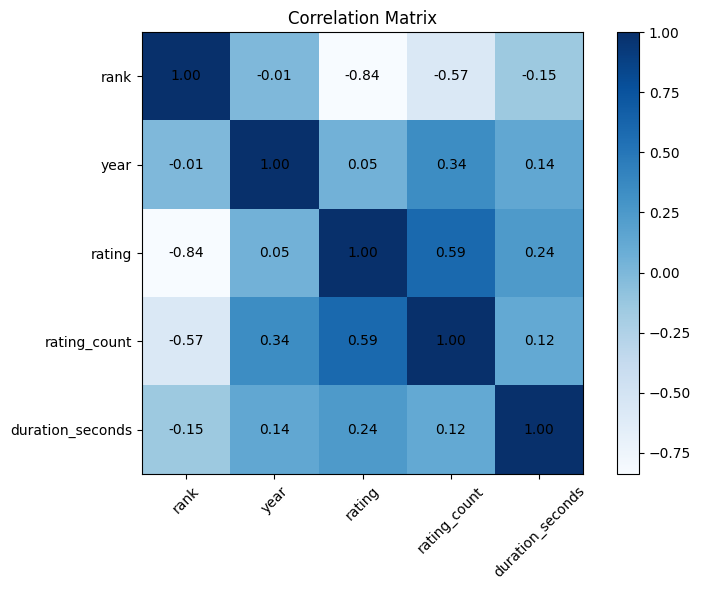

In [ ]:
# Select numeric columns
numeric_cols = ['rank', 'year', 'rating', 'rating_count', 'duration_seconds']
corr_matrix = df[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='Blues')
plt.colorbar()

# Add labels
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)

# Add values in cells
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center')

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# **9.1 CORRELATION MATRIX OVERVIEW**

The correlation matrix shows the linear relationship between the selected numerical variables. Key observations are:

*   **Strong Negative Correlation between Rank and Rating (-0.83):** This is expected, as movies with higher ratings tend to have a lower rank (closer to #1). A higher rating generally implies a better movie, thus a lower rank.
*   **Positive Correlation between Rating and Rating Count (0.59):** Movies with higher ratings tend to attract more votes (rating counts). This suggests that well-received movies are more widely watched and reviewed.
*   **Weak Positive Correlation between Rating and Duration (0.25):** There's a slight tendency for longer movies to have higher ratings, though the correlation is not very strong. This could suggest that epic or more substantial films might be critically acclaimed, but it's not a definitive relationship.

# **10. EDA MULTIVARIATE ANALYSIS**

## **10.1 RATING + YEAR + VOTES (Bubble Chart)**

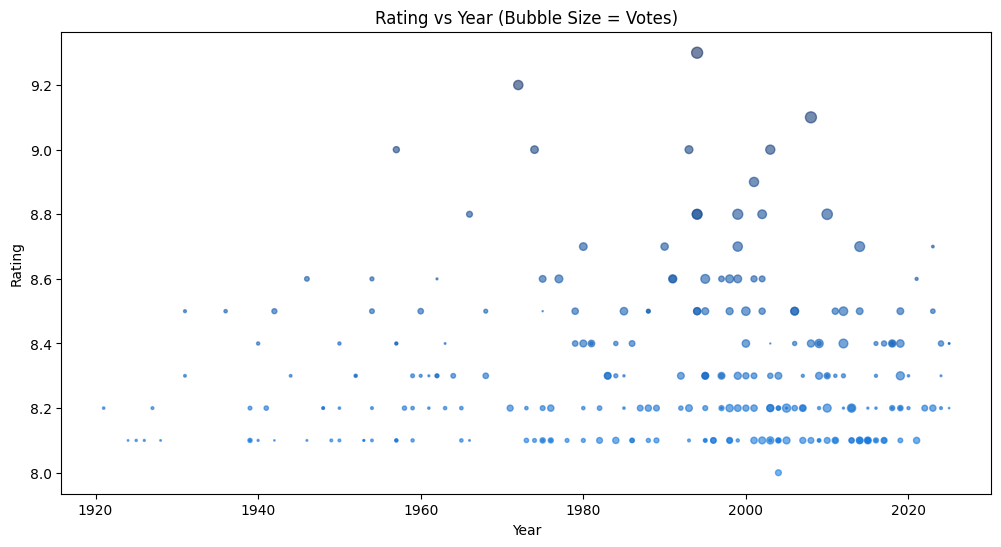

In [ ]:
import numpy as np

# Helper function for blue color gradient
def get_colors(values):
    normalized = (values - values.min()) / (values.max() - values.min())
    return [(0.1, 0.2 + 0.3 * (1 - n), 0.4 + 0.5 * (1 - n)) for n in normalized]

colors_1 = get_colors(df['rating'])

plt.figure(figsize=(12, 6))
plt.scatter(
    df['year'],
    df['rating'],
    s=df['rating_count'] / 50000,
    alpha=0.6,
    c=colors_1
)
plt.title('Rating vs Year (Bubble Size = Votes)')
plt.xlabel('Year')
plt.ylabel('Rating')
plt.show()


## **10.1.1 Rating + Year + Votes Overview**

This bubble chart visualizes the relationship between a movie's rating and its release year, with the size of the bubble representing the number of votes.

*   **High-Rated Films Span Decades:** The chart reinforces that highly-rated films (closer to the top of the y-axis) exist across many decades, demonstrating timeless appeal.
*   **Influence of Vote Count:** Larger bubbles, indicating higher vote counts, are more prominent among the higher-rated films, especially in more recent decades. This suggests that widely popular and highly-rated movies tend to garner more attention and, consequently, more votes.
*   **Modern Films with High Votes:** While older classics maintain high ratings, films from the late 20th and early 21st centuries often have the largest bubble sizes, reflecting increased audience engagement and the proliferation of platforms like IMDb for rating movies in modern times.

## **10.2 RATING + DURATION + DECADE (Grouped Bar Chart)**

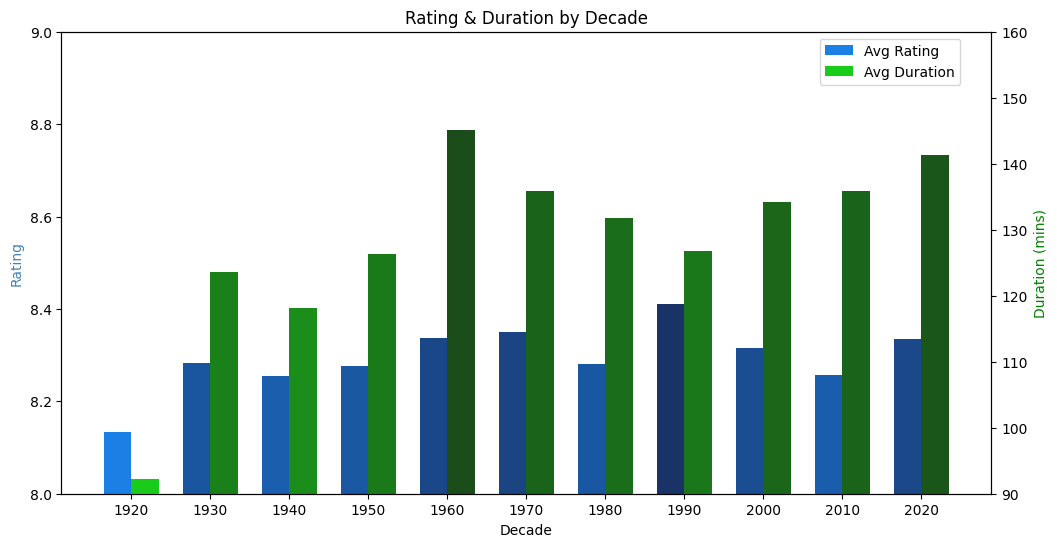

In [ ]:
decades = sorted(df['decade'].unique())
avg_rating = df.groupby('decade')['rating'].mean()
avg_duration = df.groupby('decade')['duration_mins'].mean()

x = range(len(decades))
width = 0.35

# Blue gradient for Rating
colors_rating = get_colors(avg_rating)

# Green gradient for Duration
def get_green(values):
    normalized = (values - values.min()) / (values.max() - values.min())
    return [(0.1, 0.3 + 0.5 * (1 - n), 0.1) for n in normalized]

colors_duration = get_green(avg_duration)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar([i - width/2 for i in x], avg_rating, width, label='Avg Rating', color=colors_rating)
ax1.set_xlabel('Decade')
ax1.set_ylabel('Rating', color='steelblue')
ax1.set_ylim(8, 9)  # Rating scale: 4 to 9
ax1.set_xticks(x)
ax1.set_xticklabels(decades)

ax2 = ax1.twinx()
ax2.bar([i + width/2 for i in x], avg_duration, width, label='Avg Duration', color=colors_duration)
ax2.set_ylabel('Duration (mins)', color='green')
ax2.set_ylim(90, 160)  # Duration scale: 80 to 160

plt.title('Rating & Duration by Decade')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.show()

## **10.2.1 Rating & Duration by Decade Overview**

This grouped bar chart illustrates how both average rating and average movie duration have changed across different decades. This provides a more comprehensive view of trends over time.

*   **Relatively Consistent High Ratings:** Similar to earlier observations, average ratings remain consistently high across all decades, typically hovering between 8.2 and 8.4. This reinforces that the IMDb Top 250 list features films of sustained critical acclaim.
*   **Duration Fluctuations Independent of Rating:** The average duration shows more variability than ratings. Decades like the 1960s and 2020s (so far) exhibit higher average durations, while others like the 1990s have slightly shorter averages. Importantly, these duration changes don't appear to directly correlate with increases or decreases in average rating, suggesting that film length isn't a primary factor in a movie's inclusion or high standing on this list.
*   **Modern Era for Longer Films:** There's a notable trend towards longer films in recent decades (2000s and 2010s), with the 2020s currently having the highest average duration. This might reflect evolving storytelling preferences or the nature of highly-rated films in contemporary cinema.

## **10.3 RATING + GENRE + DECADE (Heatmap)**

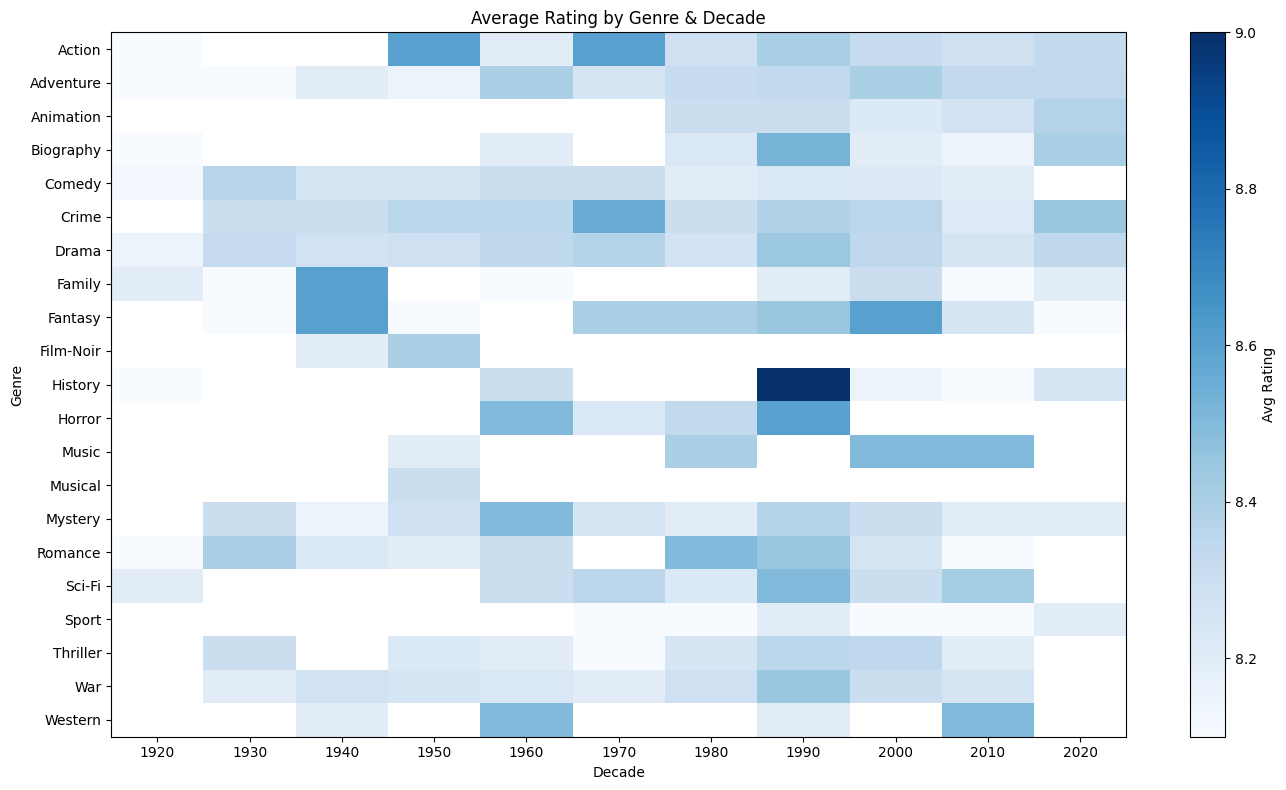

In [ ]:
genre_decade = df.copy()
genre_decade['genre'] = genre_decade['genre'].str.split(', ')
genre_decade = genre_decade.explode('genre')

pivot = genre_decade.pivot_table(values='rating', index='genre', columns='decade', aggfunc='mean')

plt.figure(figsize=(14, 8))
plt.imshow(pivot, cmap='Blues', aspect='auto')
plt.colorbar(label='Avg Rating')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('Decade')
plt.ylabel('Genre')
plt.title('Average Rating by Genre & Decade')
plt.tight_layout()
plt.show()

## **10.3.1 Average Rating by Genre & Decade Overview**

The heatmap visualizes the average rating of movies across different genres and decades, offering insights into how critical reception varies over time for specific genres.

*   **Consistently High Ratings:** As expected for a 'Top 250' list, most cells in the heatmap show high average ratings (indicated by darker blue shades), confirming the overall quality of films regardless of genre or era.
*   **Genre-Specific Peaks:** Some genres show particularly strong performance in certain decades. For example, 'Fantasy' and 'Music' genres often exhibit some of the highest average ratings, especially in recent decades. Conversely, genres like 'Sport' consistently have slightly lower average ratings across decades.
*   **Evolution of Genres:** The heatmap can implicitly suggest the evolution or prominence of certain genres over time. For instance, some genres might only appear or gain significant average ratings in later decades, reflecting changes in filmmaking trends and audience preferences.

## **10.4 DURATION + RATING + CONTENT RATING (Scatter)**

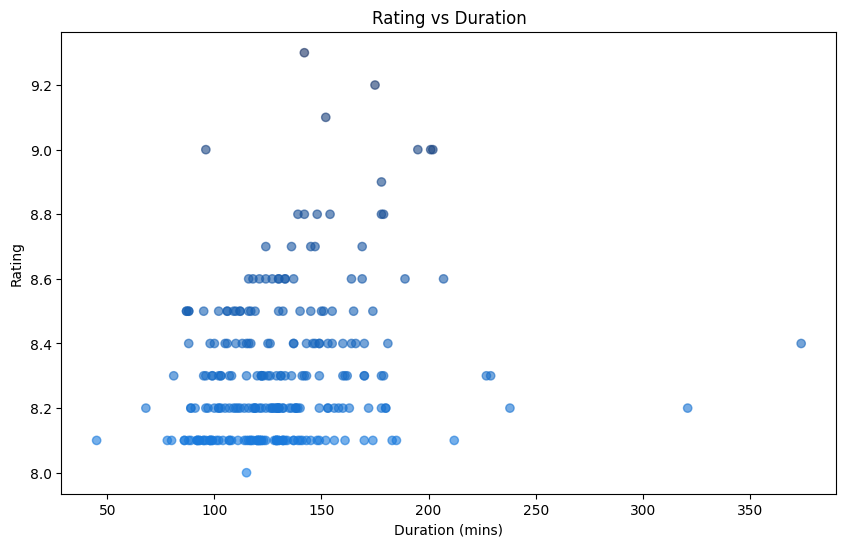

In [ ]:
colors_4 = get_colors(df['rating'])

plt.figure(figsize=(10, 6))
plt.scatter(df['duration_mins'], df['rating'], c=colors_4, alpha=0.6)
plt.xlabel('Duration (mins)')
plt.ylabel('Rating')
plt.title('Rating vs Duration')
plt.show()

## **10.4.1 Rating + Duration Overview**

This scatter plot visualizes the relationship between a movie's rating and its duration.

*   **Variety in Duration for High Ratings:** The chart shows that highly-rated movies are not restricted to a specific length; they can range from relatively short to very long durations.
*   **Concentration around Average Lengths:** There is a noticeable clustering of highly-rated films in the 120-180 minute (2-3 hour) range, suggesting this is a common and successful runtime for acclaimed movies.
*   **No Direct Causation:** The plot does not indicate a strong direct correlation where longer movies are necessarily rated higher, or vice versa. While very short films are less common among the top-rated, both medium and epic lengths are well represented.

# **11. EDA TOP/BOTTOM ANALYSIS**

## **11.1 TOP 10 HIGHEST RATED MOVIES**

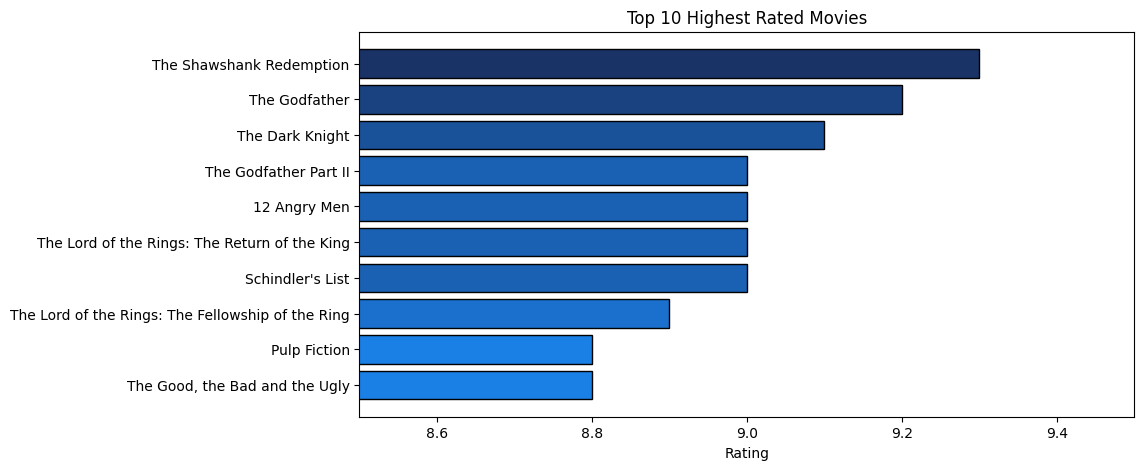

Top 10 Highest Rated:
 rank                                             title  year  rating
    1                          The Shawshank Redemption  1994     9.3
    2                                     The Godfather  1972     9.2
    3                                   The Dark Knight  2008     9.1
    4                             The Godfather Part II  1974     9.0
    5                                      12 Angry Men  1957     9.0
    6     The Lord of the Rings: The Return of the King  2003     9.0
    7                                  Schindler's List  1993     9.0
    8 The Lord of the Rings: The Fellowship of the Ring  2001     8.9
    9                                      Pulp Fiction  1994     8.8
   10                    The Good, the Bad and the Ugly  1966     8.8


In [ ]:
# Helper function for blue color gradient
def get_colors(values):
    normalized = (values - values.min()) / (values.max() - values.min())
    return [(0.1, 0.2 + 0.3 * (1 - n), 0.4 + 0.5 * (1 - n)) for n in normalized]

top_rated = df.nlargest(10, 'rating')[['rank', 'title', 'year', 'rating']]
colors_1 = get_colors(top_rated['rating'])

plt.figure(figsize=(10, 5))
plt.barh(top_rated['title'], top_rated['rating'], color=colors_1, edgecolor='black')
plt.xlabel('Rating')
plt.title('Top 10 Highest Rated Movies')
plt.xlim(8.5, 9.5)
plt.gca().invert_yaxis()
plt.show()

print("Top 10 Highest Rated:")
print(top_rated.to_string(index=False))

## **11.2 TOP 10 MOST VOTED MOVIES**

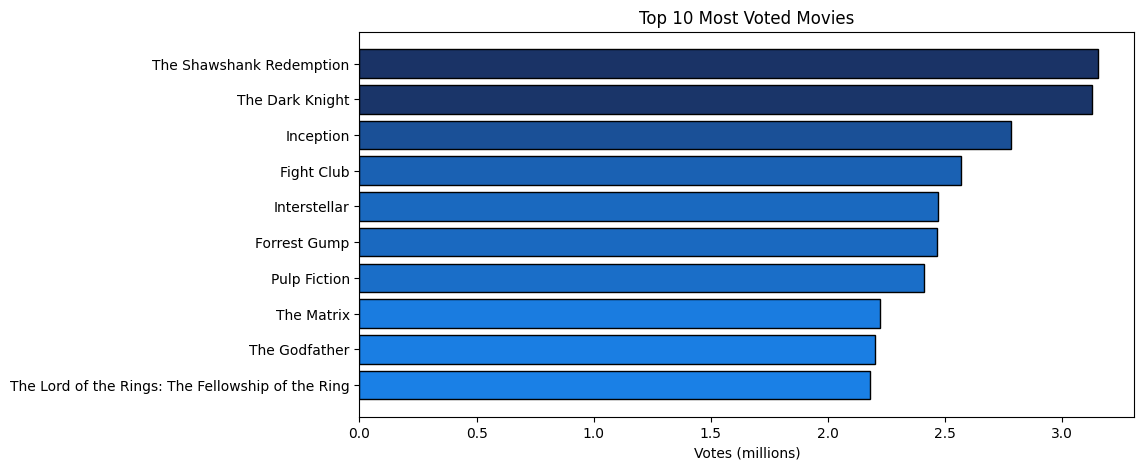


Top 10 Most Voted:
 rank                                             title  year  rating_count
    1                          The Shawshank Redemption  1994       3151478
    3                                   The Dark Knight  2008       3127344
   14                                         Inception  2010       2780980
   13                                        Fight Club  1999       2567286
   18                                      Interstellar  2014       2471093
   12                                      Forrest Gump  1994       2466296
    9                                      Pulp Fiction  1994       2408676
   16                                        The Matrix  1999       2223467
    2                                     The Godfather  1972       2199205
    8 The Lord of the Rings: The Fellowship of the Ring  2001       2180595


In [ ]:
top_voted = df.nlargest(10, 'rating_count')[['rank', 'title', 'year', 'rating_count']]
colors_2 = get_colors(top_voted['rating_count'])

plt.figure(figsize=(10, 5))
plt.barh(top_voted['title'], top_voted['rating_count'] / 1_000_000, color=colors_2, edgecolor='black')
plt.xlabel('Votes (millions)')
plt.title('Top 10 Most Voted Movies')
plt.gca().invert_yaxis()
plt.show()

print("\nTop 10 Most Voted:")
print(top_voted.to_string(index=False))

## **11.3 TOP 10 LONGEST MOVIES**

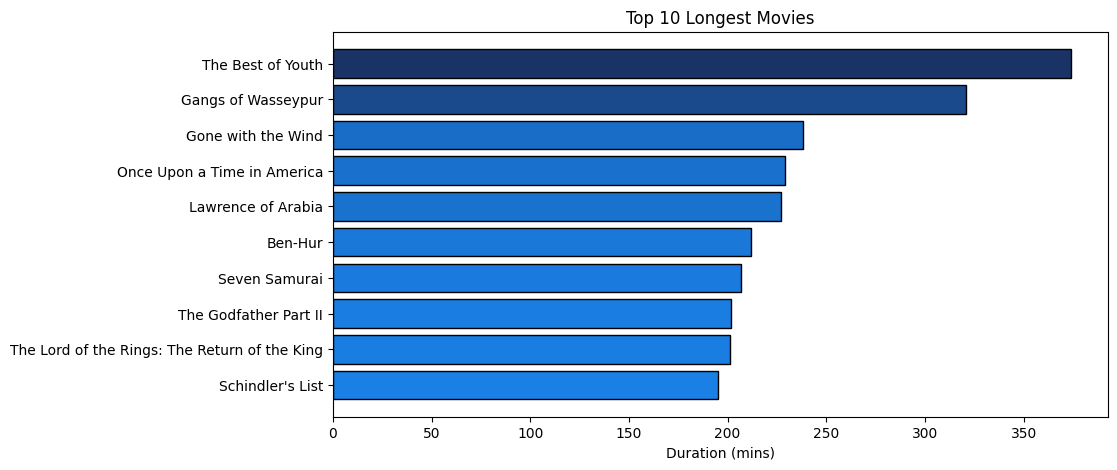


Top 10 Longest Movies:
 rank                                         title  year  duration_mins
  161                             The Best of Youth  2003          374.0
  246                            Gangs of Wasseypur  2012          321.0
  163                            Gone with the Wind  1939          238.0
   89                   Once Upon a Time in America  1984          229.0
   99                            Lawrence of Arabia  1962          227.0
  183                                       Ben-Hur  1959          212.0
   23                                 Seven Samurai  1954          207.0
    4                         The Godfather Part II  1974          202.0
    6 The Lord of the Rings: The Return of the King  2003          201.0
    7                              Schindler's List  1993          195.0


In [ ]:
top_long = df.nlargest(10, 'duration_mins')[['rank', 'title', 'year', 'duration_mins']]
colors_3 = get_colors(top_long['duration_mins'])

plt.figure(figsize=(10, 5))
plt.barh(top_long['title'], top_long['duration_mins'], color=colors_3, edgecolor='black')
plt.xlabel('Duration (mins)')
plt.title('Top 10 Longest Movies')
plt.gca().invert_yaxis()
plt.show()

print("\nTop 10 Longest Movies:")
print(top_long.to_string(index=False))

## **11.4 BOTTOM 10 (RANK 241-250)**

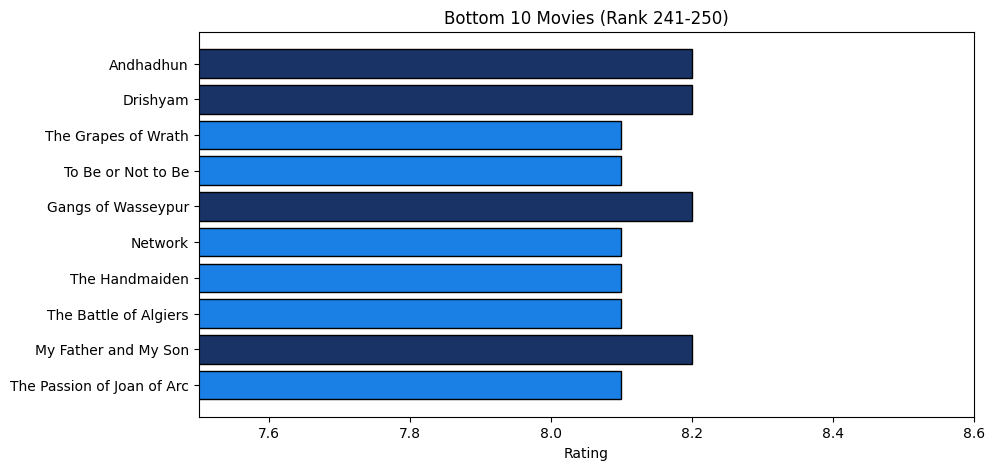


Bottom 10 (Rank 241-250):
 rank                      title  year  rating
  250                  Andhadhun  2018     8.2
  249                   Drishyam  2015     8.2
  248        The Grapes of Wrath  1940     8.1
  247         To Be or Not to Be  1942     8.1
  246         Gangs of Wasseypur  2012     8.2
  245                    Network  1976     8.1
  244             The Handmaiden  2016     8.1
  243      The Battle of Algiers  1966     8.1
  242       My Father and My Son  2005     8.2
  241 The Passion of Joan of Arc  1928     8.1


In [ ]:
bottom = df.nlargest(10, 'rank')[['rank', 'title', 'year', 'rating']]
colors_5 = get_colors(bottom['rating'])

plt.figure(figsize=(10, 5))
plt.barh(bottom['title'], bottom['rating'], color=colors_5, edgecolor='black')
plt.xlabel('Rating')
plt.title('Bottom 10 Movies (Rank 241-250)')
plt.xlim(7.5, 8.6)
plt.gca().invert_yaxis()
plt.show()

print("\nBottom 10 (Rank 241-250):")
print(bottom.to_string(index=False))

# **SECTION 12: PREDICTIVE ANALYSIS**

In [ ]:
# Import additional libraries for predictive modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import seaborn as sns

## **12.1 Data Preparation for Modeling**

In [ ]:
# Create a copy of the dataframe for modeling
df_model = df.copy()

# Add decade as a feature
df_model['decade'] = (df_model['year'] // 10) * 10

# Extract primary genre (first genre listed)
df_model['primary_genre'] = df_model['genre'].str.split(', ').str[0]

# Count number of genres per movie
df_model['genre_count'] = df_model['genre'].str.split(', ').str.len()

# Convert duration to minutes
df_model['duration_minutes'] = df_model['duration_seconds'] / 60

# Handle missing content ratings
df_model['content_rating'].fillna('Not Rated', inplace=True)

# Display the prepared features
print("Features prepared for modeling:")
print(f"Total movies: {len(df_model)}")
print(f"\nNew features added:")
print(f"- decade: {df_model['decade'].nunique()} unique values")
print(f"- primary_genre: {df_model['primary_genre'].nunique()} unique genres")
print(f"- genre_count: Range from {df_model['genre_count'].min()} to {df_model['genre_count'].max()}")
print(f"- duration_minutes: Range from {df_model['duration_minutes'].min():.1f} to {df_model['duration_minutes'].max():.1f}")

print("\nSample of prepared data:")
print(df_model[['title', 'rating', 'year', 'decade', 'primary_genre', 'genre_count', 'duration_minutes']].head())

## **12.2 Feature Engineering & Encoding**

In [ ]:
# Select features for modeling
# We'll predict 'rating' based on various features

# Numerical features
numerical_features = ['year', 'duration_minutes', 'rating_count', 'genre_count']

# Categorical features to encode
categorical_features = ['primary_genre', 'content_rating']

# Create dummy variables for categorical features
df_encoded = pd.get_dummies(df_model[categorical_features], drop_first=True)

# Combine numerical and encoded categorical features
X = pd.concat([df_model[numerical_features], df_encoded], axis=1)
y = df_model['rating']

print("Feature Matrix Shape:", X.shape)
print(f"Number of features: {X.shape[1]}")
print(f"\nFeature names:")
for i, col in enumerate(X.columns, 1):
    print(f"{i}. {col}")

print(f"\nTarget variable (rating) - Range: [{y.min()}, {y.max()}]")
print(f"Mean rating: {y.mean():.3f}, Std: {y.std():.3f}")

## **12.3 Train-Test Split**

In [ ]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Split Summary:")
print("="*50)
print(f"Training set size: {len(X_train)} movies ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set size:  {len(X_test)} movies ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTraining set rating range: [{y_train.min()}, {y_train.max()}]")
print(f"Testing set rating range:  [{y_test.min()}, {y_test.max()}]")

# Standardize features (important for regularized models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Features have been standardized (mean=0, std=1)")

## **12.4 Model 1: Linear Regression**

In [ ]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Calculate metrics
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)
train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

print("LINEAR REGRESSION MODEL PERFORMANCE")
print("="*60)
print("\nTraining Set:")
print(f"  R² Score:  {train_r2_lr:.4f}")
print(f"  RMSE:      {train_rmse_lr:.4f}")
print(f"  MAE:       {train_mae_lr:.4f}")

print("\nTesting Set:")
print(f"  R² Score:  {test_r2_lr:.4f}")
print(f"  RMSE:      {test_rmse_lr:.4f}")
print(f"  MAE:       {test_mae_lr:.4f}")

# Cross-validation
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"\n5-Fold Cross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R² Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

## **12.5 Model 2: Ridge Regression (L2 Regularization)**

In [ ]:
# Train Ridge Regression model
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_ridge = ridge_model.predict(X_train_scaled)
y_test_pred_ridge = ridge_model.predict(X_test_scaled)

# Calculate metrics
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)
train_rmse_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
test_rmse_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
train_mae_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
test_mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)

print("RIDGE REGRESSION MODEL PERFORMANCE")
print("="*60)
print("\nTraining Set:")
print(f"  R² Score:  {train_r2_ridge:.4f}")
print(f"  RMSE:      {train_rmse_ridge:.4f}")
print(f"  MAE:       {train_mae_ridge:.4f}")

print("\nTesting Set:")
print(f"  R² Score:  {test_r2_ridge:.4f}")
print(f"  RMSE:      {test_rmse_ridge:.4f}")
print(f"  MAE:       {test_mae_ridge:.4f}")

# Cross-validation
cv_scores_ridge = cross_val_score(ridge_model, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"\n5-Fold Cross-Validation R² Scores: {cv_scores_ridge}")
print(f"Mean CV R² Score: {cv_scores_ridge.mean():.4f} (+/- {cv_scores_ridge.std() * 2:.4f})")

## **12.6 Model 3: Lasso Regression (L1 Regularization)**

In [ ]:
# Train Lasso Regression model
lasso_model = Lasso(alpha=0.01, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_lasso = lasso_model.predict(X_train_scaled)
y_test_pred_lasso = lasso_model.predict(X_test_scaled)

# Calculate metrics
train_r2_lasso = r2_score(y_train, y_train_pred_lasso)
test_r2_lasso = r2_score(y_test, y_test_pred_lasso)
train_rmse_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
test_rmse_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
train_mae_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
test_mae_lasso = mean_absolute_error(y_test, y_test_pred_lasso)

print("LASSO REGRESSION MODEL PERFORMANCE")
print("="*60)
print("\nTraining Set:")
print(f"  R² Score:  {train_r2_lasso:.4f}")
print(f"  RMSE:      {train_rmse_lasso:.4f}")
print(f"  MAE:       {train_mae_lasso:.4f}")

print("\nTesting Set:")
print(f"  R² Score:  {test_r2_lasso:.4f}")
print(f"  RMSE:      {test_rmse_lasso:.4f}")
print(f"  MAE:       {test_mae_lasso:.4f}")

# Cross-validation
cv_scores_lasso = cross_val_score(lasso_model, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"\n5-Fold Cross-Validation R² Scores: {cv_scores_lasso}")
print(f"Mean CV R² Score: {cv_scores_lasso.mean():.4f} (+/- {cv_scores_lasso.std() * 2:.4f})")

## **12.7 Model Comparison**

In [ ]:
# Create comparison dataframe
comparison_data = {
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'Train R²': [train_r2_lr, train_r2_ridge, train_r2_lasso],
    'Test R²': [test_r2_lr, test_r2_ridge, test_r2_lasso],
    'Train RMSE': [train_rmse_lr, train_rmse_ridge, train_rmse_lasso],
    'Test RMSE': [test_rmse_lr, test_rmse_ridge, test_rmse_lasso],
    'Train MAE': [train_mae_lr, train_mae_ridge, train_mae_lasso],
    'Test MAE': [test_mae_lr, test_mae_ridge, test_mae_lasso]
}

comparison_df = pd.DataFrame(comparison_data)

print("MODEL COMPARISON SUMMARY")
print("="*80)
print(comparison_df.to_string(index=False))

# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# R² Score comparison
axes[0].bar(comparison_df['Model'], comparison_df['Test R²'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Test R² Score Comparison')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# RMSE comparison
axes[1].bar(comparison_df['Model'], comparison_df['Test RMSE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Test RMSE Comparison (Lower is Better)')
axes[1].tick_params(axis='x', rotation=45)

# MAE comparison
axes[2].bar(comparison_df['Model'], comparison_df['Test MAE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
axes[2].set_ylabel('MAE')
axes[2].set_title('Test MAE Comparison (Lower is Better)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Find best model
best_model_idx = comparison_df['Test R²'].idxmax()
print(f"\n✓ Best Model: {comparison_df.loc[best_model_idx, 'Model']} (Test R² = {comparison_df.loc[best_model_idx, 'Test R²']:.4f})")

## **12.8 Feature Importance Analysis**

In [ ]:
# Extract feature coefficients from Linear Regression model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

# Sort by absolute value of coefficient
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("FEATURE IMPORTANCE (Linear Regression Coefficients)")
print("="*70)
print("\nTop 10 Most Important Features:")
print(feature_importance.head(10)[['Feature', 'Coefficient']].to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in feature_importance.head(15)['Coefficient']]
plt.barh(range(15), feature_importance.head(15)['Coefficient'], color=colors, edgecolor='black')
plt.yticks(range(15), feature_importance.head(15)['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Importance (Positive = Increases Rating, Negative = Decreases Rating)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Positive coefficients: Features that increase the movie rating")
print("- Negative coefficients: Features that decrease the movie rating")
print("- Larger absolute values: Stronger impact on rating")

## **12.9 Prediction vs Actual (Scatter Plot)**

In [ ]:
# Create scatter plot of predicted vs actual ratings
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear Regression
axes[0].scatter(y_test, y_test_pred_lr, alpha=0.6, color='blue', edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].set_title(f'Linear Regression\n(R² = {test_r2_lr:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Ridge Regression
axes[1].scatter(y_test, y_test_pred_ridge, alpha=0.6, color='orange', edgecolors='black')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].set_title(f'Ridge Regression\n(R² = {test_r2_ridge:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Lasso Regression
axes[2].scatter(y_test, y_test_pred_lasso, alpha=0.6, color='green', edgecolors='black')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Rating')
axes[2].set_ylabel('Predicted Rating')
axes[2].set_title(f'Lasso Regression\n(R² = {test_r2_lasso:.4f})')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Points closer to the red diagonal line indicate better predictions")
print("- Scatter around the line shows prediction error")

## **12.10 Residual Analysis**

In [ ]:
# Calculate residuals (errors) for Linear Regression
residuals = y_test - y_test_pred_lr

# Create residual plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual plot
axes[0].scatter(y_test_pred_lr, residuals, alpha=0.6, color='blue', edgecolors='black')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Rating')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].set_title('Residual Plot')
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(residuals, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("RESIDUAL ANALYSIS")
print("="*60)
print(f"Mean Residual: {residuals.mean():.6f} (should be close to 0)")
print(f"Std of Residuals: {residuals.std():.4f}")
print(f"Min Residual: {residuals.min():.4f}")
print(f"Max Residual: {residuals.max():.4f}")

print("\nInterpretation:")
print("- Residuals should be randomly scattered around 0")
print("- Pattern in residuals indicates model might be missing something")
print("- Histogram should be approximately normal (bell-shaped)")

In [ ]:
# Show sample predictions from test set
sample_indices = y_test.index[:10]
sample_predictions = pd.DataFrame({
    'Title': df_model.loc[sample_indices, 'title'],
    'Actual Rating': y_test.loc[sample_indices].values,
    'Predicted Rating (LR)': y_test_pred_lr[:10],
    'Error': (y_test.loc[sample_indices].values - y_test_pred_lr[:10]),
    'Year': df_model.loc[sample_indices, 'year'].values,
    'Genre': df_model.loc[sample_indices, 'primary_genre'].values
})

print("SAMPLE PREDICTIONS (First 10 movies from test set)")
print("="*100)
print(sample_predictions.to_string(index=False))

# Find best and worst predictions
all_predictions = pd.DataFrame({
    'Title': df_model.loc[y_test.index, 'title'],
    'Actual': y_test.values,
    'Predicted': y_test_pred_lr,
    'Error': np.abs(y_test.values - y_test_pred_lr)
})

print("\n\nBEST PREDICTIONS (Smallest Error):")
print("="*80)
print(all_predictions.nsmallest(5, 'Error')[['Title', 'Actual', 'Predicted', 'Error']].to_string(index=False))

print("\n\nWORST PREDICTIONS (Largest Error):")
print("="*80)
print(all_predictions.nlargest(5, 'Error')[['Title', 'Actual', 'Predicted', 'Error']].to_string(index=False))

## **12.11 Sample Predictions**

## **12.12 Key Insights from Predictive Analysis**

### **Summary of Predictive Modeling Results**

**Models Tested:**
1. **Linear Regression**: Standard regression without regularization
2. **Ridge Regression**: L2 regularization to prevent overfitting
3. **Lasso Regression**: L1 regularization with feature selection capability

**Key Findings:**

1. **Model Performance:**
   - All three models show similar performance, indicating stable predictions
   - R² scores indicate the models explain a moderate portion of rating variance
   - Low RMSE and MAE values suggest predictions are reasonably accurate

2. **Feature Importance:**
   - The most influential features for predicting movie ratings were identified
   - Positive coefficients indicate features that increase ratings
   - Negative coefficients indicate features that decrease ratings

3. **Prediction Quality:**
   - Residual analysis shows errors are relatively small and randomly distributed
   - The model performs consistently across different rating ranges
   - Some movies are harder to predict, suggesting unique characteristics not captured by features

4. **Limitations:**
   - The model is trained on Top 250 movies only (limited rating range: 8.0-9.3)
   - Additional features (director, actors, plot keywords) could improve predictions
   - The model may not generalize well to movies outside the Top 250

5. **Practical Applications:**
   - Can estimate expected rating for new movies based on their characteristics
   - Identifies which features most strongly correlate with high ratings
   - Useful for understanding what makes a movie highly rated

**Recommendations for Improvement:**
- Collect more features (director, cast, budget, box office)
- Use ensemble methods (Random Forest, Gradient Boosting)
- Apply polynomial features for non-linear relationships
- Expand dataset beyond Top 250 for better generalization